# Evaluación Formativa 1 — Código del informe
## Dataset: *Give Me Some Credit* (riesgo crediticio)

**MCDI501 - Estadística Computacional para la Toma de Decisiones**
Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello

Este cuaderno reproduce todos los resultados del informe de ejemplo de la Formativa 1 y genera sus cinco
figuras (`fig_panorama.png`, `fig_distribuciones.png`, `fig_correlacion.png`, `fig_mora_edad.png` y
`fig_mora_atrasos.png`). Sigue el mismo orden del informe:

1. Estadística descriptiva (ID1.2)
2. Estimación puntual e intervalos de confianza (ID1.3)
3. Pruebas de hipótesis (ID1.4): *t* de Welch, $\chi^2$ de independencia y *z* de dos proporciones

Semilla fija: `42`.

## 0. Configuración y carga de datos

El archivo `cs-training.csv` se descarga desde Kaggle (competencia *Give Me Some Credit*). Si no está en
la carpeta de trabajo, el cuaderno lo lee desde un espejo público en GitHub.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SEED = 42
np.random.seed(SEED)

LOCAL = 'cs-training.csv'
MIRROR = ('https://github.com/jpmaidana/MCDI501-202682/blob/main/data/raw/cs-training.csv')
df = pd.read_csv(LOCAL, index_col=0) if os.path.exists(LOCAL) else pd.read_csv(MIRROR, index_col=0)

TARGET = 'SeriousDlqin2yrs'
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.to_csv('cs-training.csv')

### Estilo de las figuras
Paleta común para las cinco figuras del informe: fondo crema, verde azulado para la serie principal,
terracota para la clase minoritaria y ocre para las líneas de referencia.

In [3]:
TEAL  = '#2e6b75'   # serie principal
TERRA = '#a35140'   # clase minoritaria / textos de referencia
OCHRE = '#c4862f'   # líneas de referencia (media, mediana)
STEM  = '#bdb3a3'   # tallos de los gráficos lollipop
BG    = '#f6f1ea'   # fondo de los ejes
GRID  = '#ddd5c6'   # líneas de grilla

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200,
    'font.family': 'serif', 'font.size': 10,
    'axes.facecolor': BG, 'axes.edgecolor': '#8c8578',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'normal', 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

## 1. Estadística descriptiva (ID1.2)

### 1.1 Tipos de variables y medidas resumen
Una variable objetivo binaria y diez predictores numéricos: tres continuos (utilización de crédito, ratio
de deuda, ingreso), la edad (cuasi-continua) y seis conteos.

In [4]:
tipos = pd.Series({
    'SeriousDlqin2yrs': 'Binaria (objetivo)',
    'RevolvingUtilizationOfUnsecuredLines': 'Continua',
    'age': 'Cuasi-continua',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Conteo',
    'DebtRatio': 'Continua',
    'MonthlyIncome': 'Continua',
    'NumberOfOpenCreditLinesAndLoans': 'Conteo',
    'NumberOfTimes90DaysLate': 'Conteo',
    'NumberRealEstateLoansOrLines': 'Conteo',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Conteo',
    'NumberOfDependents': 'Conteo',
}, name='Tipo')
tipos.to_frame()

,Tipo
SeriousDlqin2yrs,Binaria (objetivo)
RevolvingUtilizationOfUnsecuredLines,Continua
age,Cuasi-continua
NumberOfTime30-59DaysPastDueNotWorse,Conteo
DebtRatio,Continua
MonthlyIncome,Continua
NumberOfOpenCreditLinesAndLoans,Conteo
NumberOfTimes90DaysLate,Conteo
NumberRealEstateLoansOrLines,Conteo
NumberOfTime60-89DaysPastDueNotWorse,Conteo


In [5]:
# Tabla 1 del informe: media, mediana, desviación estándar, mínimo y máximo
desc = df.drop(columns=TARGET).describe().T[['mean', '50%', 'std', 'min', 'max']]
desc.columns = ['Media', 'Mediana', 'Desv. est.', 'Mínimo', 'Máximo']
desc.round(2)

,Media,Mediana,Desv. est.,Mínimo,Máximo
RevolvingUtilizationOfUnsecuredLines,6.05,0.15,249.76,0.0,50708.0
age,52.30,52.00,14.77,0.0,109.0
NumberOfTime30-59DaysPastDueNotWorse,0.42,0.00,4.19,0.0,98.0
DebtRatio,353.01,0.37,2037.82,0.0,329664.0
MonthlyIncome,6670.22,5400.00,14384.67,0.0,3008750.0
NumberOfOpenCreditLinesAndLoans,8.45,8.00,5.15,0.0,58.0
NumberOfTimes90DaysLate,0.27,0.00,4.17,0.0,98.0
NumberRealEstateLoansOrLines,1.02,1.00,1.13,0.0,54.0
NumberOfTime60-89DaysPastDueNotWorse,0.24,0.00,4.16,0.0,98.0
NumberOfDependents,0.76,0.00,1.12,0.0,20.0


### 1.2 Calidad de datos
Desbalance del objetivo, datos faltantes, duplicados y valores imposibles o codificados.

In [6]:
n = len(df)
print(f"Tasa de morosidad          : {df[TARGET].mean()*100:.2f}%")
print(f"Faltantes MonthlyIncome    : {df['MonthlyIncome'].isna().sum():,} ({df['MonthlyIncome'].isna().mean()*100:.1f}%)")
print(f"Faltantes NumberOfDependents: {df['NumberOfDependents'].isna().sum():,} ({df['NumberOfDependents'].isna().mean()*100:.1f}%)")
print(f"Filas duplicadas           : {df.duplicated().sum():,}")
print(f"Registros con age = 0      : {(df['age'] == 0).sum()}")
atrasos = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse']
for c in atrasos:
    print(f"Códigos 96/98 en {c[:30]:30s}: {(df[c] >= 96).sum()}")

Tasa de morosidad          : 6.68%
Faltantes MonthlyIncome    : 29,731 (19.8%)
Faltantes NumberOfDependents: 3,924 (2.6%)
Filas duplicadas           : 609
Registros con age = 0      : 1
Códigos 96/98 en NumberOfTime30-59DaysPastDueNo: 269
Códigos 96/98 en NumberOfTimes90DaysLate       : 269
Códigos 96/98 en NumberOfTime60-89DaysPastDueNo: 269


Registros con age = 0      : 1
Códigos 96/98 en NumberOfTime30-59DaysPastDueNo: 269
Códigos 96/98 en NumberOfTimes90DaysLate       : 269
Códigos 96/98 en NumberOfTime60-89DaysPastDueNo: 269


### Figura 1 - Variable objetivo y datos faltantes

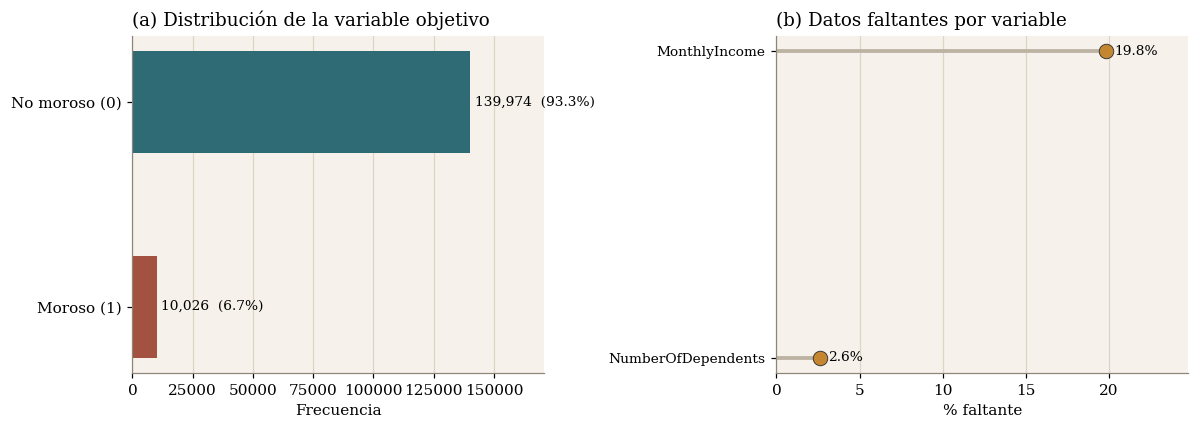

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (a) distribución de la variable objetivo (barras horizontales)
vc = df[TARGET].value_counts().sort_index()
labels = ['No moroso (0)', 'Moroso (1)']
ax[0].barh(labels, vc.values, color=[TEAL, TERRA], height=0.5)
ax[0].invert_yaxis()
for i, v in enumerate(vc.values):
    ax[0].text(v + 2000, i, f'{v:,}  ({v/n*100:.1f}%)', va='center', fontsize=9)
ax[0].set_xlim(0, vc.max() * 1.22)
ax[0].set_xlabel('Frecuencia')
ax[0].set_title('(a) Distribución de la variable objetivo')
ax[0].grid(axis='y', visible=False)

# (b) porcentaje de faltantes por variable (lollipop horizontal)
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
y = np.arange(len(miss))
ax[1].hlines(y, 0, miss.values, color=STEM, lw=2.5)
ax[1].scatter(miss.values, y, s=90, color=OCHRE, edgecolor='#333333', linewidth=0.6, zorder=3)
for i, v in enumerate(miss.values):
    ax[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax[1].set_yticks(y)
ax[1].set_yticklabels(miss.index, fontsize=9)
ax[1].invert_yaxis()
ax[1].set_xlim(0, miss.max() * 1.25)
ax[1].set_xlabel('% faltante')
ax[1].set_title('(b) Datos faltantes por variable')
ax[1].grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig('fig_panorama.png', bbox_inches='tight')
plt.show()

### Figura 2 - Distribución de tres variables representativas
El ingreso se recorta al percentil 99 solo para visualizarlo; los cálculos usan todos los datos.

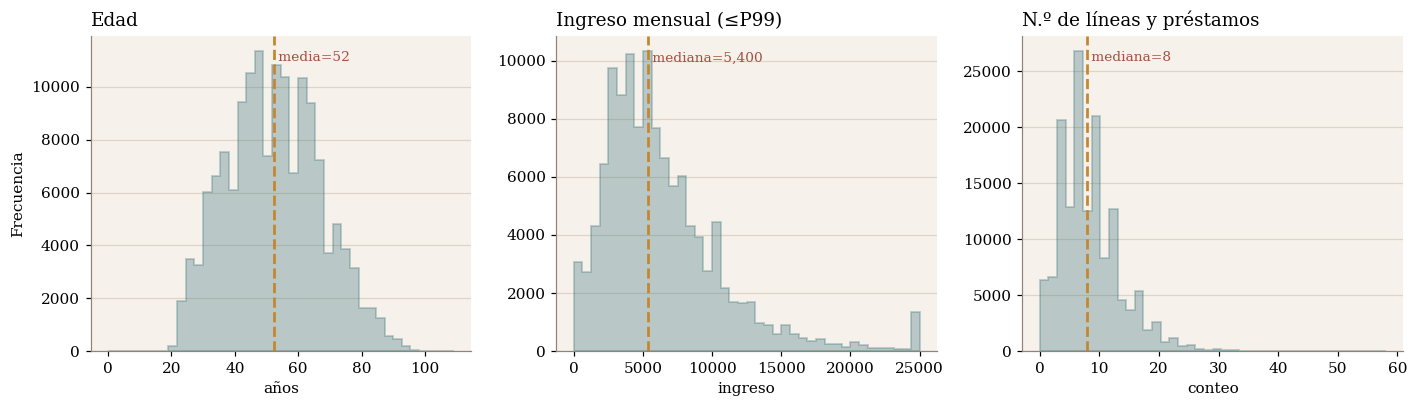

In [8]:
inc = df['MonthlyIncome'].dropna()
lines = df['NumberOfOpenCreditLinesAndLoans']
paneles = [
    (df['age'], 'Edad', 'años', 'media', df['age'].mean()),
    (inc.clip(upper=inc.quantile(0.99)), 'Ingreso mensual (≤P99)', 'ingreso', 'mediana', inc.median()),
    (lines, 'N.º de líneas y préstamos', 'conteo', 'mediana', lines.median()),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (x, titulo, xlab, nombre, ref) in zip(axes, paneles):
    ax.hist(x, bins=40, histtype='stepfilled', color=TEAL, alpha=0.3,
            edgecolor=TEAL, linewidth=1.2)
    ax.axvline(ref, color=OCHRE, ls='--', lw=1.8)
    ax.text(ref, ax.get_ylim()[1] * 0.93, f' {nombre}={ref:,.0f}', color=TERRA, fontsize=9, va='center')
    ax.set_title(titulo)
    ax.set_xlabel(xlab)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('fig_distribuciones.png', bbox_inches='tight')
plt.show()

### Figura 3 - Matriz de correlaciones (triángulo inferior)

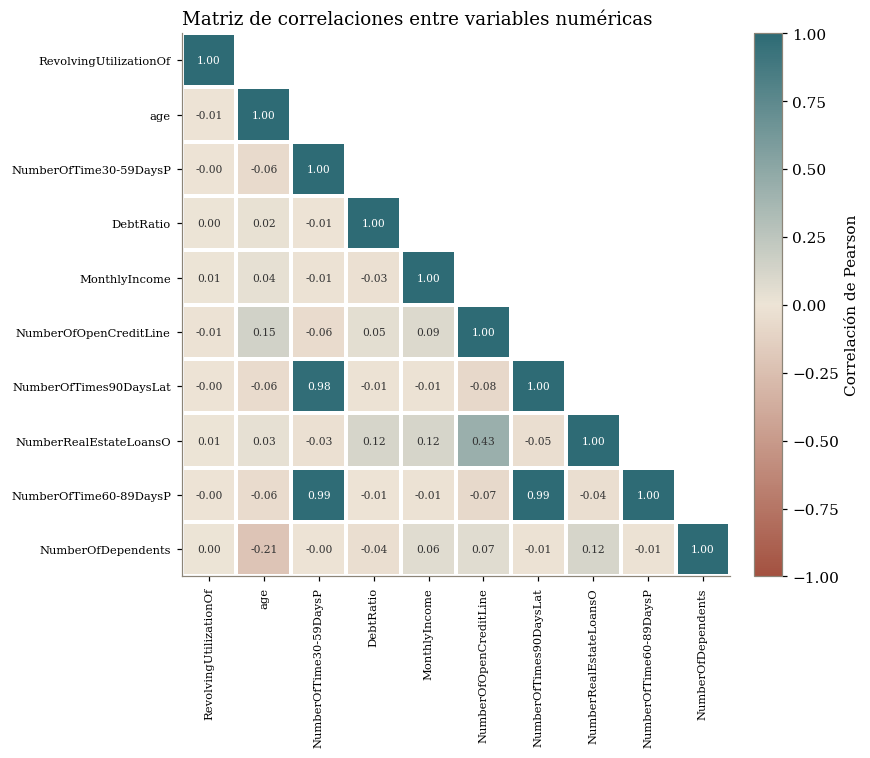

NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate                 0.993
                                      NumberOfTime30-59DaysPastDueNotWorse    0.987
NumberOfTimes90DaysLate               NumberOfTime30-59DaysPastDueNotWorse    0.984
NumberRealEstateLoansOrLines          NumberOfOpenCreditLinesAndLoans         0.434
NumberOfDependents                    age                                    -0.213
dtype: float64

In [9]:
corr = df.drop(columns=TARGET).corr()
k = len(corr)
mask = np.triu(np.ones((k, k), dtype=bool), k=1)   # oculta el triángulo superior
cmap = LinearSegmentedColormap.from_list('div', [TERRA, '#ede4d6', TEAL])

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor('white')
ax.grid(False)
im = ax.pcolormesh(np.ma.masked_array(corr.values, mask), cmap=cmap, vmin=-1, vmax=1,
                   edgecolors='white', linewidth=1.5)
ax.invert_yaxis()
for i in range(k):
    for j in range(i + 1):
        v = corr.values[i, j]
        ax.text(j + 0.5, i + 0.5, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.5 else '#333333')
etq = [c[:22] for c in corr.columns]
ax.set_xticks(np.arange(k) + 0.5)
ax.set_xticklabels(etq, rotation=90, fontsize=7.5)
ax.set_yticks(np.arange(k) + 0.5)
ax.set_yticklabels(etq, fontsize=7.5)
ax.set_title('Matriz de correlaciones entre variables numéricas')
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('Correlación de Pearson')

plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

# Pares con mayor |r| fuera de la diagonal
pares = corr.where(np.tril(np.ones((k, k), dtype=bool), k=-1)).stack()
pares.reindex(pares.abs().sort_values(ascending=False).index).head(5).round(3)

**Lectura.** Las tres variables de atrasos están casi perfectamente correlacionadas entre sí
($r$ entre 0,98 y 0,99): miden, en la práctica, el mismo comportamiento. El resto de las correlaciones
son débiles a moderadas.

In [10]:
# Correlación de cada variable con el objetivo (se menciona en la interpretación del informe)
df.corr()[TARGET].drop(TARGET).sort_values().round(4)

age                                    -0.1154
NumberOfOpenCreditLinesAndLoans        -0.0297
MonthlyIncome                          -0.0197
DebtRatio                              -0.0076
NumberRealEstateLoansOrLines           -0.0070
RevolvingUtilizationOfUnsecuredLines   -0.0018
NumberOfDependents                      0.0460
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfTimes90DaysLate                 0.1172
NumberOfTime30-59DaysPastDueNotWorse    0.1256
Name: SeriousDlqin2yrs, dtype: float64

## 2. Estimación puntual e intervalos de confianza (ID1.3)

Intervalos al 95% con la aproximación normal (Teorema Central del Límite):

- Media: $\bar{x} \pm z_{0.975}\cdot s/\sqrt{n}$
- Proporción: $\hat{p} \pm z_{0.975}\cdot\sqrt{\hat{p}(1-\hat{p})/n}$

In [11]:
z975 = stats.norm.ppf(0.975)

def ic_media(x):
    x = pd.Series(x).dropna()
    m, ee = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    return m, m - z975 * ee, m + z975 * ee, len(x)

def ic_proporcion(x):
    p, nn = x.mean(), len(x)
    ee = np.sqrt(p * (1 - p) / nn)
    return p, p - z975 * ee, p + z975 * ee, nn

filas = []
for nombre, res in [('Edad media (años)', ic_media(df['age'])),
                    ('Ingreso mensual medio', ic_media(df['MonthlyIncome'])),
                    ('Proporción de morosidad', ic_proporcion(df[TARGET]))]:
    filas.append({'Parámetro': nombre, 'Estimación': res[0],
                  'IC 95% inf.': res[1], 'IC 95% sup.': res[2], 'n': res[3]})
tabla_ic = pd.DataFrame(filas).set_index('Parámetro')
tabla_ic.round(5)

,Estimación,IC 95% inf.,IC 95% sup.,n
Parámetro,,,,
Edad media (años),52.29521,52.22045,52.36996,150000
Ingreso mensual medio,6670.22124,6588.92485,6751.51763,120269
Proporción de morosidad,0.06684,0.06558,0.06810,150000


In [12]:
print(f"Mediana del ingreso: {df['MonthlyIncome'].median():,.0f}  (media {df['MonthlyIncome'].mean():,.0f})")
print('La media supera a la mediana: distribución asimétrica a la derecha.')
print('Con n = 120.269 el TCL hace que la media muestral sea aproximadamente normal, por lo que el IC sigue siendo válido.')

Mediana del ingreso: 5,400  (media 6,670)
La media supera a la mediana: distribución asimétrica a la derecha.
Con n = 120.269 el TCL hace que la media muestral sea aproximadamente normal, por lo que el IC sigue siendo válido.


## 3. Pruebas de hipótesis (ID1.4)

Nivel de significancia: $\alpha = 0{,}05$.

### 3.1 Prueba *t* de Welch: edad de morosos vs. no morosos
$H_0:\ \mu_{\text{moroso}} = \mu_{\text{no moroso}}$ vs. $H_1:\ \mu_{\text{moroso}} \neq \mu_{\text{no moroso}}$.
Se usa Welch porque los grupos tienen tamaños y varianzas distintos.

In [13]:
edad_mora = df.loc[df[TARGET] == 1, 'age']
edad_no   = df.loc[df[TARGET] == 0, 'age']
print(f"Varianzas: morosos = {edad_mora.var():.1f}, no morosos = {edad_no.var():.1f}")

t, p = stats.ttest_ind(edad_mora, edad_no, equal_var=False)
n1_, n0_ = len(edad_mora), len(edad_no)
sp = np.sqrt(((n1_ - 1) * edad_mora.var(ddof=1) + (n0_ - 1) * edad_no.var(ddof=1)) / (n1_ + n0_ - 2))  # desviación agrupada
d = (edad_mora.mean() - edad_no.mean()) / sp

print(f"Media morosos    : {edad_mora.mean():.2f} años (n={len(edad_mora):,})")
print(f"Media no morosos : {edad_no.mean():.2f} años (n={len(edad_no):,})")
print(f"t de Welch = {t:.2f}   valor p {'< 0.0001' if p < 1e-4 else f'= {p:.4f}'}   d de Cohen = {d:.3f}")
print('Decisión:', 'se rechaza H0' if p < 0.05 else 'no se rechaza H0')

Varianzas: morosos = 166.8, no morosos = 218.8
Media morosos    : 45.93 años (n=10,026)
Media no morosos : 52.75 años (n=139,974)
t de Welch = -50.58   valor p < 0.0001   d de Cohen = -0.465
Decisión: se rechaza H0


### 3.2 Prueba $\chi^2$ de independencia: tramo etario y morosidad

In [14]:
tramos = pd.cut(df['age'], bins=[0, 30, 45, 60, 75, 200],
                labels=['<30', '30-44', '45-59', '60-74', '75+'], right=False)
tabla = pd.crosstab(tramos, df[TARGET])
chi2, p_chi, gl, esperadas = stats.chi2_contingency(tabla)
V = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))

print(f"Chi² = {chi2:,.1f}   gl = {gl}   valor p {'< 0.0001' if p_chi < 1e-4 else f'= {p_chi:.4f}'}   V de Cramér = {V:.2f}")
print(f"Frecuencia esperada mínima: {esperadas.min():.0f} (supuesto >= 5 se cumple)")
tasa_edad = tramos.to_frame('tramo').assign(y=df[TARGET]).groupby('tramo', observed=True)['y'].mean() * 100
tasa_edad.round(1).to_frame('% morosidad')

Chi² = 1,884.9   gl = 4   valor p < 0.0001   V de Cramér = 0.11
Frecuencia esperada mínima: 590 (supuesto >= 5 se cumple)


,% morosidad
tramo,
<30,11.7
30-44,9.5
45-59,7.0
60-74,3.4
75+,2.0


### Figura 4 - Tasa de morosidad por tramo etario

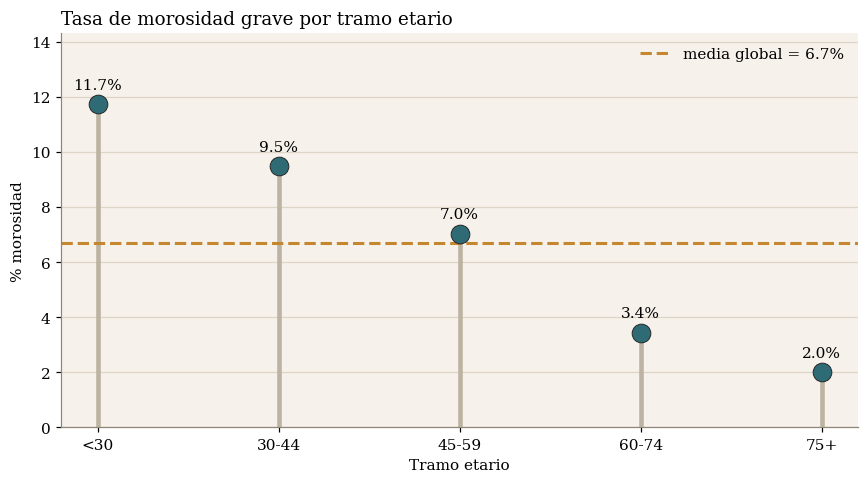

In [15]:
media_global = df[TARGET].mean() * 100
x = np.arange(len(tasa_edad))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.vlines(x, 0, tasa_edad.values, color=STEM, lw=3)
ax.scatter(x, tasa_edad.values, s=150, color=TEAL, edgecolor='#222222', linewidth=0.6, zorder=3)
for xi, v in zip(x, tasa_edad.values):
    ax.text(xi, v + 0.55, f'{v:.1f}%', ha='center', fontsize=10)
ax.axhline(media_global, color=OCHRE, ls='--', lw=2, label=f'media global = {media_global:.1f}%')
ax.set_xticks(x)
ax.set_xticklabels(tasa_edad.index)
ax.set_xlabel('Tramo etario')
ax.set_ylabel('% morosidad')
ax.set_ylim(0, tasa_edad.max() * 1.22)
ax.set_title('Tasa de morosidad grave por tramo etario')
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig('fig_mora_edad.png', bbox_inches='tight')
plt.show()

### 3.3 Prueba *z* de dos proporciones: historial de atrasos
Se compara la morosidad entre quienes tienen al menos un atraso de 30 a 59 días y quienes no tienen
ninguno. Los códigos especiales (96 y 98) se excluyen porque no representan conteos reales.

$H_0:\ p_{\geq 1} = p_{0}$ vs. $H_1:\ p_{\geq 1} \neq p_{0}$, con
$z = (\hat p_1-\hat p_0)\big/\sqrt{\hat p(1-\hat p)(1/n_1+1/n_0)}$ y $\hat p$ la proporción combinada.

In [16]:
c3059 = 'NumberOfTime30-59DaysPastDueNotWorse'
dv = df[df[c3059] < 90]                       # excluye códigos 96/98
g1 = dv.loc[dv[c3059] >= 1, TARGET]
g0 = dv.loc[dv[c3059] == 0, TARGET]

p1, p0 = g1.mean(), g0.mean()
n1, n0 = len(g1), len(g0)
p_comb = (g1.sum() + g0.sum()) / (n1 + n0)
z = (p1 - p0) / np.sqrt(p_comb * (1 - p_comb) * (1 / n1 + 1 / n0))
p_z = 2 * stats.norm.sf(abs(z))

print(f"Con >=1 atraso : {p1*100:.1f}%  (n={n1:,})")
print(f"Sin atrasos    : {p0*100:.1f}%  (n={n0:,})")
print(f"z = {z:.1f}   valor p {'< 0.0001' if p_z < 1e-4 else f'= {p_z:.4f}'}   riesgo relativo = {p1/p0:.1f}")
print('Decisión:', 'se rechaza H0' if p_z < 0.05 else 'no se rechaza H0')

Con >=1 atraso : 20.4%  (n=23,713)
Sin atrasos    : 4.0%  (n=126,018)
z = 93.3   valor p < 0.0001   riesgo relativo = 5.1
Decisión: se rechaza H0


### Figura 5 - Morosidad según el número de atrasos de 30 a 59 días

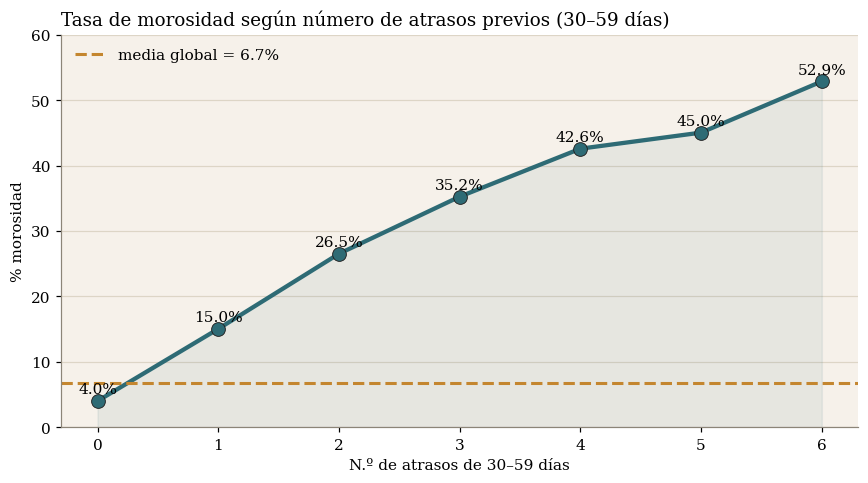

,% morosidad
NumberOfTime30-59DaysPastDueNotWorse,
0,4.0
1,15.0
2,26.5
3,35.2
4,42.6
5,45.0
6,52.9


In [17]:
tasa_atr = dv[dv[c3059] <= 6].groupby(c3059)[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(tasa_atr.index, tasa_atr.values, color=TEAL, alpha=0.08)
ax.plot(tasa_atr.index, tasa_atr.values, color=TEAL, lw=2.8, marker='o', ms=9,
        markeredgecolor='#222222', markeredgewidth=0.6)
for xi, v in zip(tasa_atr.index, tasa_atr.values):
    ax.text(xi, v + 1.2, f'{v:.1f}%', ha='center', fontsize=10)
ax.axhline(media_global, color=OCHRE, ls='--', lw=2, label=f'media global = {media_global:.1f}%')
ax.set_xlim(-0.3, 6.3)
ax.set_ylim(0, 60)
ax.set_xlabel('N.º de atrasos de 30–59 días')
ax.set_ylabel('% morosidad')
ax.set_title('Tasa de morosidad según número de atrasos previos (30–59 días)')
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig('fig_mora_atrasos.png', bbox_inches='tight')
plt.show()
tasa_atr.round(1).to_frame('% morosidad')

## 4. Síntesis

- **Descriptiva:** objetivo desbalanceado (6,7% de morosos), faltantes en ingreso (19,8%) y dependientes
  (2,6%), variables muy asimétricas, códigos especiales en los atrasos y 609 duplicados.
- **Estimación:** intervalos estrechos por el gran tamaño muestral (edad media 52,30 [52,22; 52,37];
  proporción de mora 0,0668 [0,0656; 0,0681]).
- **Pruebas:** la edad difiere entre grupos (efecto moderado, $d=-0{,}47$), y el historial de atrasos
  discrimina con más fuerza (riesgo relativo de 5,1).

In [18]:
print('Figuras generadas:', sorted(f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')))

Figuras generadas: ['fig_amount_distribution.png', 'fig_correlacion.png', 'fig_criterion_heatmap.png', 'fig_distribuciones.png', 'fig_eq5d_by_cluster.png', 'fig_eq5d_dimensions_by_cluster.png', 'fig_knowledge_dist_v2.png', 'fig_metrics_comparison_paper2.png', 'fig_mora_atrasos.png', 'fig_mora_edad.png', 'fig_panorama.png', 'fig_pca_comparison_k2_k3_k4.png', 'fig_pca_variance.png', 'fig_performance_v2.png', 'fig_q_characterization.png', 'fig_roc_rf.png']
